# Import Library

In [147]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn import metrics

# Data Understanding

In [138]:
df = pd.read_csv('/content/global air pollution dataset.csv')

In [123]:
df

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate


1. AQI Category: The overall air quality category based on the AQI value (e.g. Good, Moderate, Unhealthy).
2. Country: The name of the country where the air quality measurements were taken.
3. City: The name of the city where the air quality measurement was taken.
4. AQI Value: The overall Air Quality Index value. The higher the value, the worse the air quality.
5. CO AQI Value: AQI value specific to carbon monoxide (CO) pollutants.
6. CO AQI Category: Air quality category based on carbon monoxide levels.
7. Ozone AQI Value: AQI value specific to ground-level ozone (O₃).
8. Ozone AQI Category: Air quality category based on ozone levels.
9. NO2 AQI Value: AQI value specific to nitrogen dioxide (NO₂).
10. NO2 AQI Category: Air quality category based on nitrogen dioxide levels.
11. PM2.5 AQI Value: AQI value for fine dust particles ≤2.5 micrometres in size (Particulate Matter 2.5).
12. PM2.5 AQI Category: Air quality category based on PM2.5 levels.

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


Data has features of object and integer types.

In [99]:
df.isnull().sum()

,0
Country,427
City,1
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


A total of 427 data rows have missing values in the country feature.

In [97]:
df.duplicated().any()

np.False_

Data has no duplicates.

# Exploratory Data Analysis / EDA

In [98]:
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


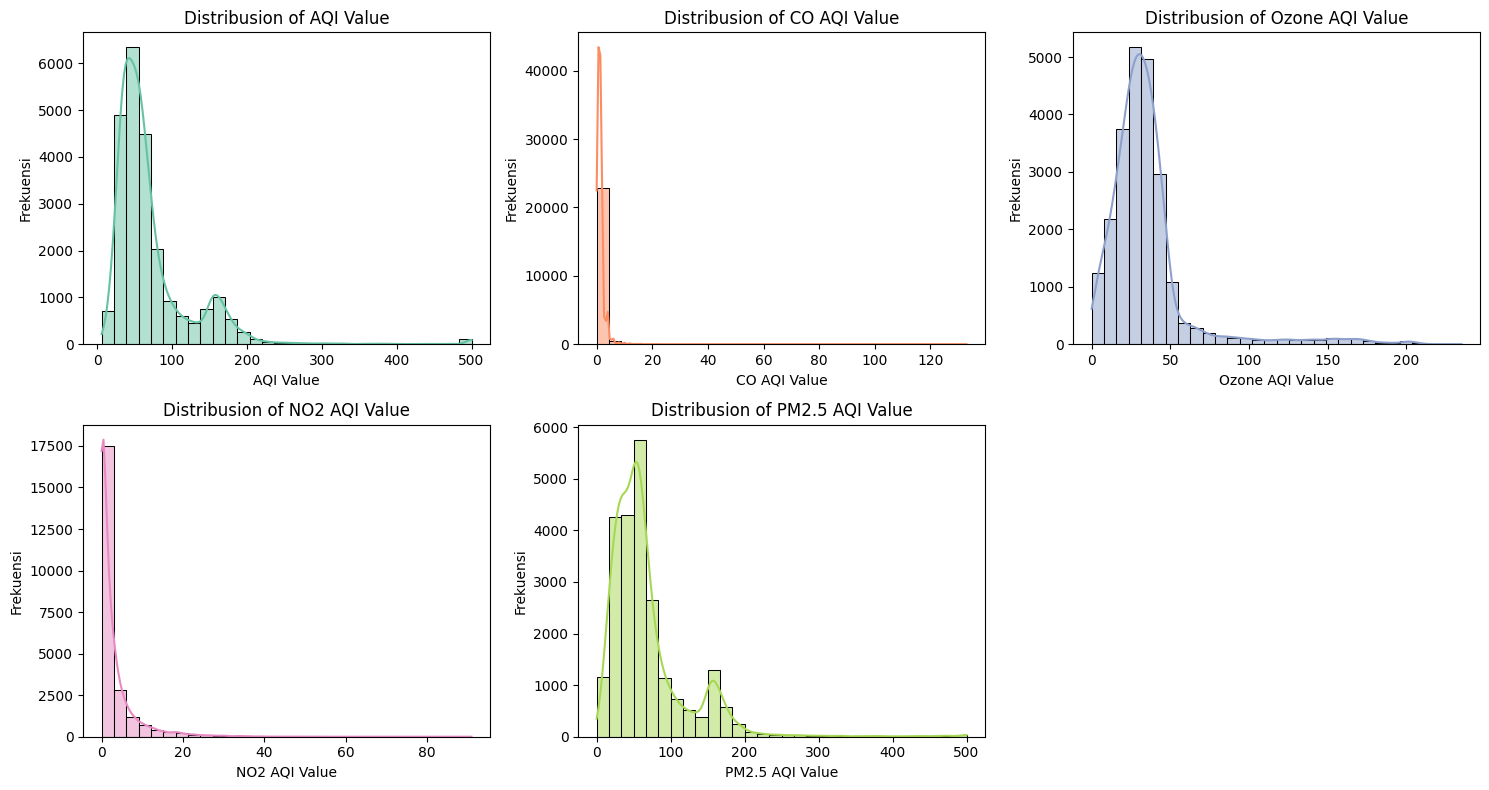

In [101]:
# List of numeric columns to be visualised
numeric_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value',
                'NO2 AQI Value', 'PM2.5 AQI Value']

rows, cols = 2, 3
plt.figure(figsize=(5 * cols, 4 * rows)) # Visualisation grid size configuration
colors = sns.color_palette("Set2", len(numeric_cols)) # Colour for each plot

# Distribution plot for each numerical column
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    if df[col].nunique() > 10:
        sns.histplot(df[col].dropna(), bins=30, kde=True, color=colors[i]) # Use histograms for continuous numerical data
    else:
        sns.countplot(x=df[col], color=colors[i]) # Use countplot for data with few unique values
    plt.title(f"Distribusion of {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

1. The overall average AQI value is around 72, which indicates that the air quality in most areas is in the Moderate category. The minimum AQI value was recorded at 6, while the maximum value reached 500, which is the upper limit of the AQI scale and reflects extremely hazardous air conditions. The median AQI value was 55, with 75% of the data falling below the value of 79, indicating that the majority of areas are within tolerable air quality, although there are a number of areas with very poor air conditions.

2. The mean air quality index value for carbon monoxide (CO) was 1.37, indicating that in general, CO concentrations in the atmosphere are quite low and not a major problem. Most areas had CO AQI values of 1, as indicated by the median and upper quartile being the same. However, the maximum CO AQI value reached 133, which is far from the majority value and can be considered an outlier reflecting extreme cases or locations with significant CO pollution.

3. The air quality index for ozone has an average of 35, which still falls into the Good to Moderate category. The median ozone value stands at 31, indicating a fairly balanced distribution. However, the maximum value reaches 235, indicating that there are certain locations with very high surface ozone concentrations. This needs attention because high concentrations of surface ozone can be harmful to health.

4. Nitrogen dioxide (NO₂) levels in the dataset show a mean of 3.06, which is very low compared to the safe limit. The median value is only 1, with 25% of areas recording a value of 0, indicating that many areas have insignificant levels of NO₂. However, there are locations with maximum values as high as 91, indicating that NO₂ pollution is still occurring in certain areas and needs to be addressed locally.

5. The average AQI value for PM2.5 stands at 68.5, which is relatively high and close to the upper limit of the Moderate category. This shows that fine particles are one of the most common and worrisome pollutants in this dataset. The median PM2.5 value is 54, while the maximum value again reaches 500, just like the total AQI, indicating that there are areas with dangerously high PM2.5 exposure. The large standard deviation (54.8) indicates significant variation from region to region.

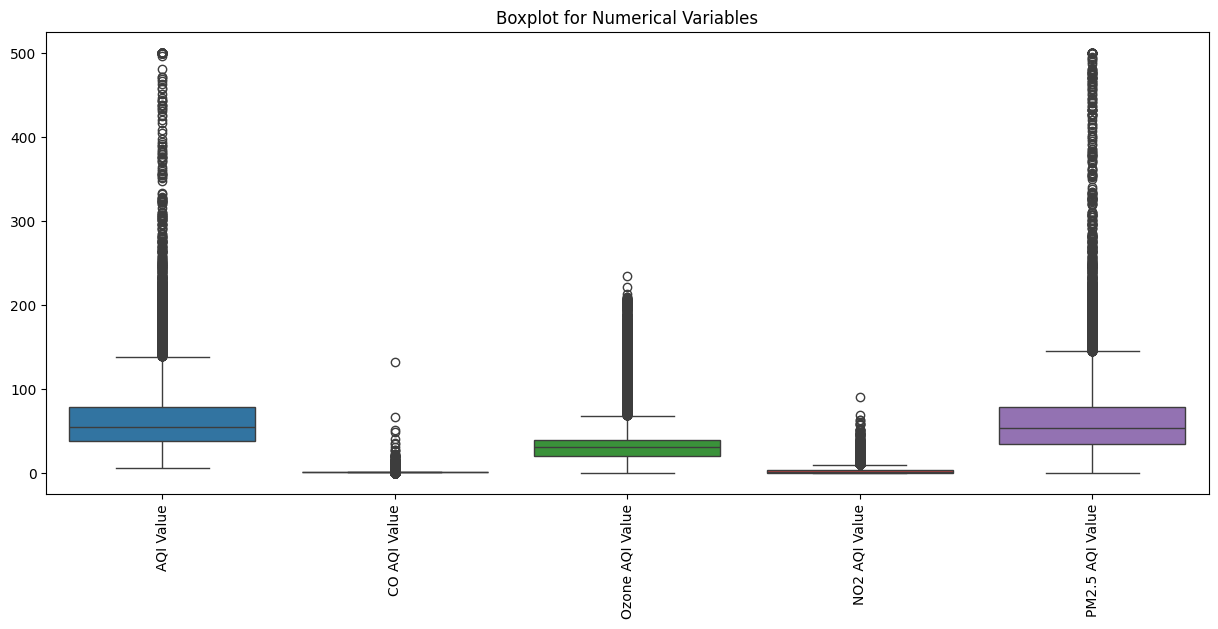

In [103]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot for Numerical Variables')
plt.xticks(rotation=90)
plt.show()

Every numerical variable has outliers and must be standardised later.

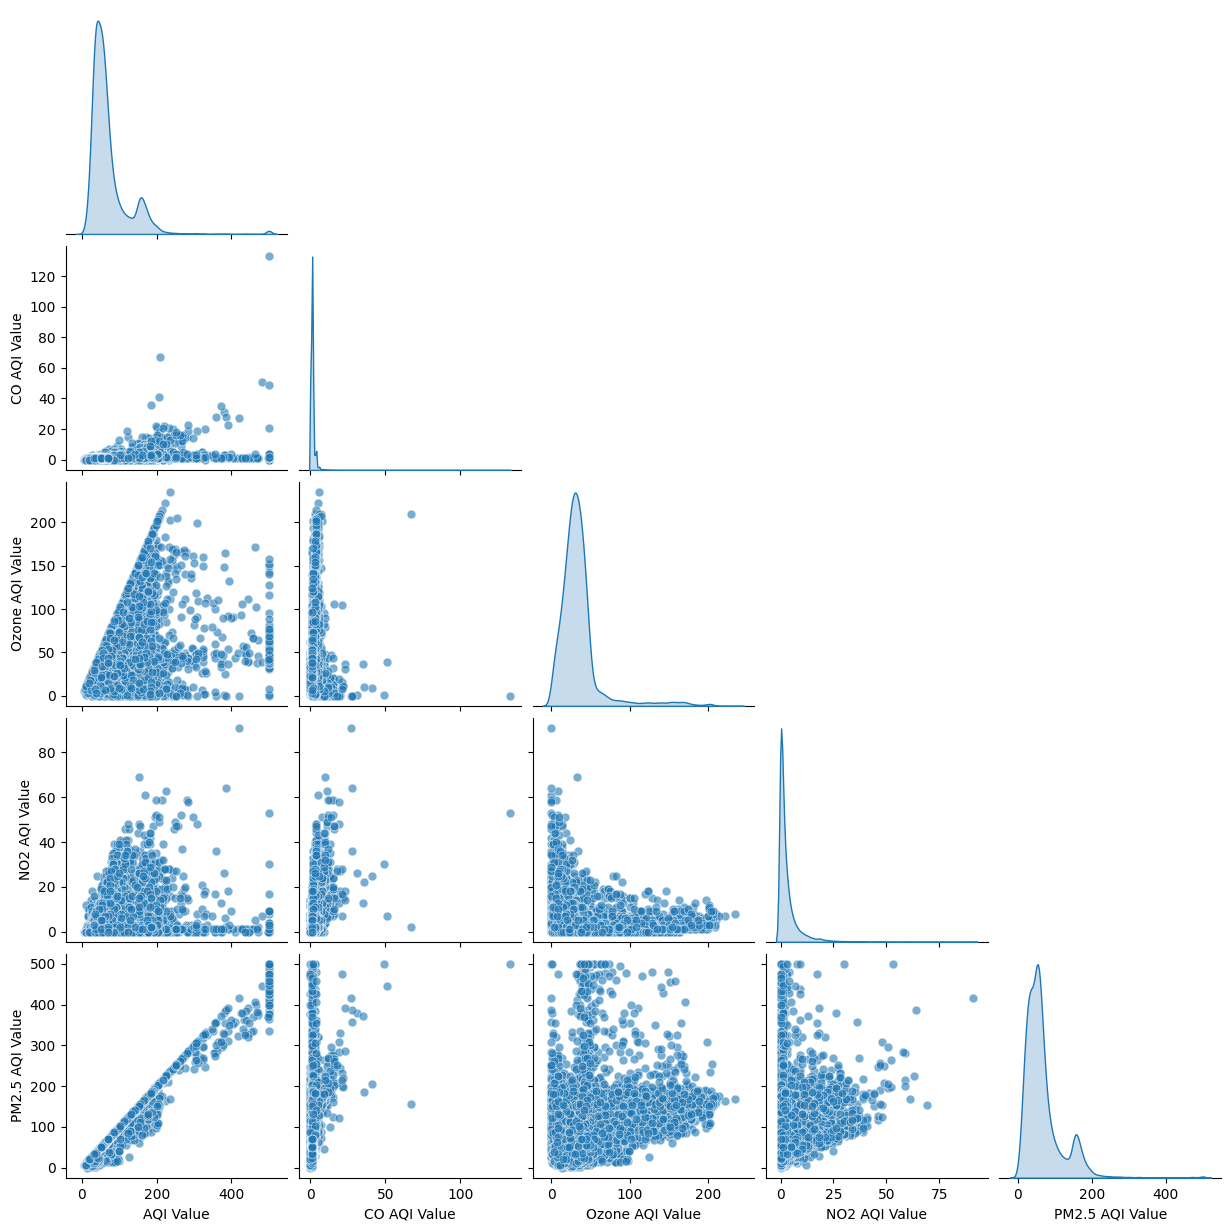

In [104]:
sns.pairplot(df, diag_kind='kde', kind='scatter', plot_kws={'alpha':0.6, 's':40}, corner=True)
plt.show()

The pair plot visualisation shows the relationship between five numerical variables in the air quality dataset, namely AQI Value, CO AQI Value, Ozone AQI Value, NO2 AQI Value, and PM2.5 AQI Value. On the diagonal, we can see the distribution of each variable. The distributions for AQI Value and PM2.5 AQI Value appear positively skewed, i.e. most of the values are low but there are some extreme values that are very high. Meanwhile, CO AQI Value and NO2 AQI Value show a dense concentration of data at small values (near zero), indicating that the majority of areas have low levels of CO and NO₂ pollutants.

The relationship between the variables can be observed on the outer diagonal. AQI Value shows the strongest correlation with PM2.5 AQI Value, as seen from the scattering pattern that follows an upward and dense direction. This indicates that fine particulate matter (PM2.5) is a major contributor to the poor air quality index. The relationship between AQI Value and Ozone AQI Value is also positive, but more diffuse, indicating that surface ozone also affects AQI although not as strongly as PM2.5. In contrast, the relationships of AQI Value with CO AQI Value and NO2 AQI Value appear weak and do not show a clear linear pattern, which means that these two pollutants have less influence on the overall AQI.

Meanwhile, correlations between fellow pollutants (such as between CO and PM2.5, or NO2 and Ozone) generally do not show a strong relationship, which could be due to differences in pollution sources or formation mechanisms. Overall, this visualisation makes it clear that PM2.5 plays a dominant role in shaping AQI values, and shows skewed distribution patterns in most features, which is important to note in further modelling or data transformation.

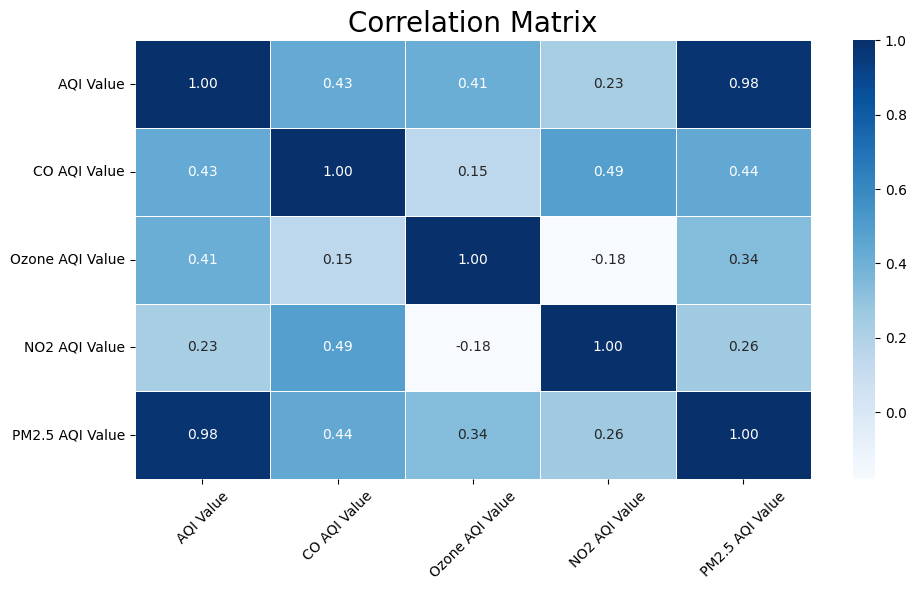

In [105]:
# Plot correlation matrix
plt.figure(figsize=(10, 6))  # Set figure size
correlation_matrix = df[numeric_cols].corr().round(2)  # Calculate and round correlation values
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix", fontsize=20)  # Title for the plot
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.yticks(rotation=0)   # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()

Convert categorical features into a numerical format that can be processed by machine learning algorithms. Each unique category in a categorical column is converted to a binary column (0 or 1), so that the model can recognize the existence of that category without assuming any order or weight between categories. This process is important because most ML models cannot handle non-numerical data directly, and one-hot encoding ensures the categorical information remains correctly represented without causing numerical bias.

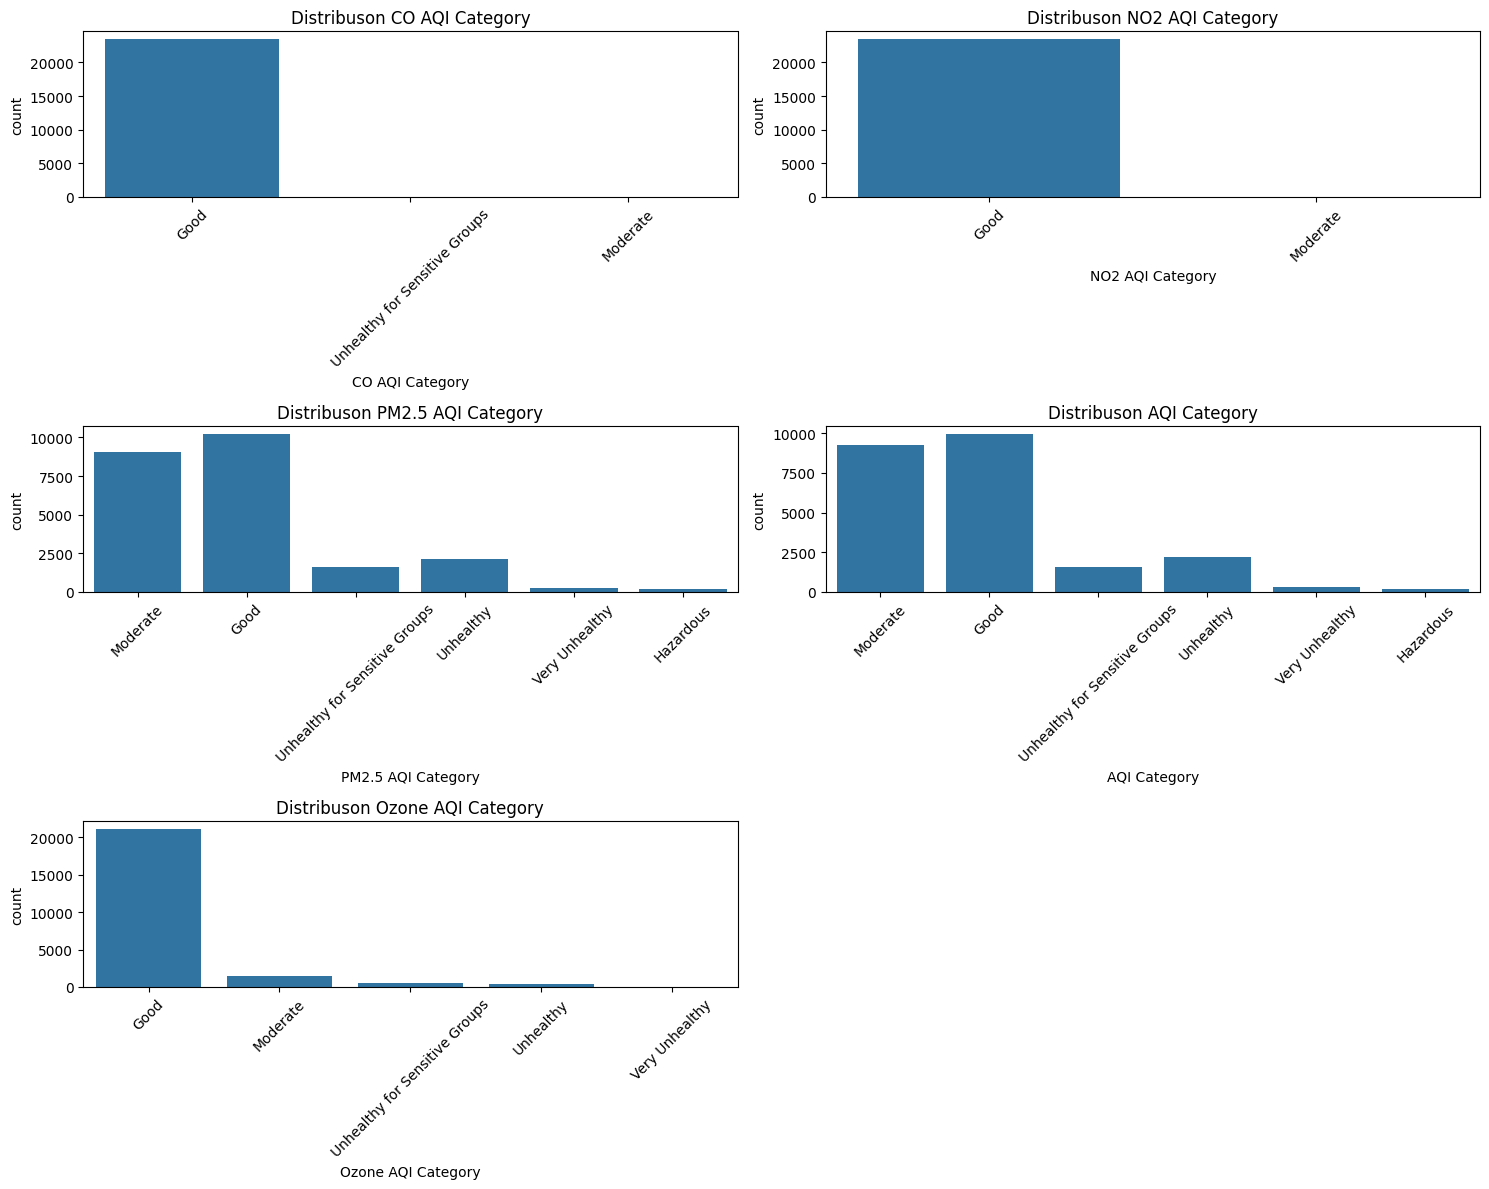

In [112]:
# Visualisation of categorical variable distributions
categorical_cols = ['CO AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category',
               'AQI Category', 'Ozone AQI Category']

plt.figure(figsize=(15, 12)) # Ploting
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribuson {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The distribution of categories in the data shows significant imbalance in most variables. The CO AQI Category consists of 3 unique categories, but is heavily dominated by the Good category (23,460 data), while Moderate and Unhealthy for Sensitive Groups only appear 2 and 1 times respectively. The NO2 AQI Category has 2 categories, also very unbalanced, with Good totalling 23,448 and Moderate only 15. The PM2.5 AQI Category includes 6 unique categories, with a more varied distribution: Good (10,208), Moderate (9,075), then a significant drop in severe categories such as Unhealthy (2,129) and Hazardous (172). The AQI Category as an overall indicator also consists of 6 categories with a similar pattern: Good and Moderate dominate, while Very Unhealthy and Hazardous are very rare. Finally, the Ozone AQI Category has 5 categories, dominated by Good (21,069), with the other categories totalling far fewer. Overall, the majority of categorical features in this dataset are imbalanced, with a strong dominance by the Good category.

# Data Preparation

In [139]:
df = df.drop(columns=['Country', 'City']) # Drop Features

Removing Country and City variables as they are not relevant for analysis due to their unique nature.

In [140]:
scaler = StandardScaler() # Scaler initialisation
df[numeric_cols] = scaler.fit_transform(df[numeric_cols]) # Fit and transform numeric columns

Numerical data that used to have outliers is now standardised for better analysis.

In [141]:
df = pd.get_dummies(df, columns=categorical_cols) # One hot Encoding

Based on the correlation matrix, it can be seen that PM2.5 AQI Value has the strongest correlation to AQI Value with a value of 0.98, indicating that these fine particles are a major contributor to the overall poor air quality. A moderate correlation is also seen between AQI and CO AQI Value (0.43) and Ozone AQI Value (0.41), signalling that they also influence the air quality index although not as strongly as PM2.5. In contrast, NO2 AQI Value is only weakly correlated (0.23) to AQI, indicating a relatively small influence. In addition, CO and NO2 show a moderate correlation with each other (0.49), which likely comes from the same pollution sources such as vehicle emissions. On the other hand, the negative correlation between Ozone and NO2 (-0.18) indicates the presence of chemical interactions in the atmosphere, for example in the formation process of tropospheric ozone. Overall, this visualisation confirms that PM2.5 is the main indicator of air quality, while other pollutants play a more limited or specific role.

In [135]:
df

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,CO AQI Category_Good,CO AQI Category_Moderate,CO AQI Category_Unhealthy for Sensitive Groups,NO2 AQI Category_Good,NO2 AQI Category_Moderate,...,AQI Category_Hazardous,AQI Category_Moderate,AQI Category_Unhealthy,AQI Category_Unhealthy for Sensitive Groups,AQI Category_Very Unhealthy,Ozone AQI Category_Good,Ozone AQI Category_Moderate,Ozone AQI Category_Unhealthy,Ozone AQI Category_Unhealthy for Sensitive Groups,Ozone AQI Category_Very Unhealthy
0,-0.374832,-0.201071,0.028696,-0.583048,-0.319731,True,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
1,-0.553232,-0.201071,-1.074581,-0.392717,-0.502229,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,-0.107233,-0.201071,0.135464,-0.202386,-0.045985,True,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
3,-0.678111,-0.201071,-0.042484,-0.583048,-0.885473,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,-0.892190,-0.746915,-0.469558,-0.583048,-1.140970,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23458,1.997878,0.890617,4.228264,-0.202386,2.107485,True,False,False,True,False,...,False,False,True,False,False,False,False,True,False,False
23459,-0.392672,-0.201071,-0.540737,0.368608,-0.337981,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
23460,-0.392672,-0.201071,-0.469558,-0.392717,-0.337981,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
23461,-0.018034,-0.201071,0.313412,-0.202386,0.045264,True,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False


# Data Splitting

In [142]:
X = df.drop(columns=["AQI Value"])
y = df["AQI Value"]

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Split the dataset into 80% training data and 20% test data.

In [144]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (18770, 26)
y_train shape: (18770,)
X_test shape: (4693, 26)
y_test shape: (4693,)


The data has been divided into 18,770 training data and 4,693 test data, each with 26 input features. The number of target labels in both sets matches, so they are ready to be used for model training and evaluation.

# Modeling

In [149]:
# Fungsi evaluasi
def cross_val(model):
    return cross_val_score(model, X, y, cv=10).mean()

def print_evaluate(true, pred):
    mae = metrics.mean_absolute_error(true, pred)
    mse = metrics.mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(true, pred)
    print(f"MAE: {mae:.4f}\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR2 Square: {r2:.4f}")
    print("_________________________________________")

def evaluate(true, pred):
    mae = metrics.mean_absolute_error(true, pred)
    mse = metrics.mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(true, pred)
    return mae, mse, rmse, r2

# Simpan hasil
results_df = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])

In [156]:
# ====================== 1. LINEAR REGRESSION ======================
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

train_pred = lin_reg.predict(X_train)
test_pred = lin_reg.predict(X_test)

print("Linear Regression - Test Set")
print_evaluate(y_test, test_pred)
print("Linear Regression - Train Set")
print_evaluate(y_train, train_pred)

results_df = pd.concat([results_df, pd.DataFrame([[
    "Linear Regression", *evaluate(y_test, test_pred), cross_val(LinearRegression())
]], columns=results_df.columns)])

# ====================== 2. POLYNOMIAL REGRESSION ======================
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

train_pred = poly_reg.predict(X_train_poly)
test_pred = poly_reg.predict(X_test_poly)

print("Polynomial Regression - Test Set")
print_evaluate(y_test, test_pred)
print("Polynomial Regression - Train Set")
print_evaluate(y_train, train_pred)

results_df = pd.concat([results_df, pd.DataFrame([[
    "Polynomial Regression", *evaluate(y_test, test_pred), cross_val(LinearRegression())
]], columns=results_df.columns)])

# ====================== 3. RANDOM FOREST REGRESSOR ======================
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_reg.fit(X_train, y_train)

train_pred = rf_reg.predict(X_train)
test_pred = rf_reg.predict(X_test)

print("Random Forest Regressor - Test Set")
print_evaluate(y_test, test_pred)
print("Random Forest Regressor - Train Set")
print_evaluate(y_train, train_pred)

results_df = pd.concat([results_df, pd.DataFrame([[
    "Random Forest Regressor", *evaluate(y_test, test_pred), cross_val(RandomForestRegressor())
]], columns=results_df.columns)])

Linear Regression - Test Set
MAE: 0.0684
MSE: 0.0112
RMSE: 0.1061
R2 Square: 0.9889
_________________________________________
Linear Regression - Train Set
MAE: 0.0684
MSE: 0.0117
RMSE: 0.1083
R2 Square: 0.9882
_________________________________________
Polynomial Regression - Test Set
MAE: 0.0423
MSE: 0.0060
RMSE: 0.0777
R2 Square: 0.9941
_________________________________________
Polynomial Regression - Train Set
MAE: 0.0405
MSE: 0.0044
RMSE: 0.0661
R2 Square: 0.9956
_________________________________________
Random Forest Regressor - Test Set
MAE: 0.0033
MSE: 0.0018
RMSE: 0.0422
R2 Square: 0.9982
_________________________________________
Random Forest Regressor - Train Set
MAE: 0.0010
MSE: 0.0002
RMSE: 0.0137
R2 Square: 0.9998
_________________________________________


In [157]:
# FINAL RESULTS
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,0.068357,0.011247,0.106053,0.988910,0.988155
1,Polynomial Regression,0.042268,0.006031,0.077661,0.994053,0.988155
2,Random Forest Regressor,0.003304,0.001783,0.042226,0.998242,0.998574
3,Linear Regression,0.068357,0.011247,0.106053,0.988910,0.988155
4,Polynomial Regression,0.042268,0.006031,0.077661,0.994053,0.988155
5,Random Forest Regressor,0.003304,0.001783,0.042226,0.998242,0.998613


Based on the evaluation results of three regression models, namely Linear Regression, Polynomial Regression, and Random Forest Regressor, there is a consistent improvement in performance as the complexity of the model increases. Linear Regression produced an R² value of 0.9889 with MAE of 0.0684 and RMSE of 0.1061, indicating that the model was able to explain almost all the variation in the data, although the prediction error was still relatively high. Polynomial Regression performed better with R² increasing to 0.9941, and MAE and RMSE decreasing to 0.0423 and 0.0777 respectively, indicating that the addition of non-linearity helped the model capture more complex relationships between variables.

Meanwhile, the Random Forest Regressor gave the best results among the three, with an R² of 0.9982, MAE of only 0.0033, and RMSE of 0.0422, making it the most accurate model in predicting the test data. It also had the highest cross-validation value (0.9986), reflecting its consistent performance on different data. Overall, Random Forest proved to be the most superior in terms of accuracy and generalization, although its interpretability was lower than linear regression. Thus, model selection can be tailored according to needs-if model interpretation is important, linear regression can be used; but if accuracy is a top priority, Random Forest Regressor is a better choice.

# Features Important of the Best Models

In [154]:
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance - Random Forest Regressor")
print(rf_importance_df)

Feature Importance - Random Forest Regressor
                                              Feature    Importance
3                                     PM2.5 AQI Value  7.326017e-01
16                             AQI Category_Hazardous  1.910312e-01
15                                  AQI Category_Good  3.232586e-02
19        AQI Category_Unhealthy for Sensitive Groups  1.994372e-02
1                                     Ozone AQI Value  1.292291e-02
18                             AQI Category_Unhealthy  8.631434e-03
20                        AQI Category_Very Unhealthy  7.553985e-04
0                                        CO AQI Value  6.376378e-04
17                              AQI Category_Moderate  5.421826e-04
2                                       NO2 AQI Value  4.379896e-04
24  Ozone AQI Category_Unhealthy for Sensitive Groups  5.504636e-05
22                        Ozone AQI Category_Moderate  4.958818e-05
21                            Ozone AQI Category_Good  2.095130e-05
23 

Based on the feature importance results from the Random Forest Regressor model, the PM2.5 AQI Value variable is the most influential feature with a contribution of 73%, followed by AQI Category_Hazardous at 19%. Meanwhile, other features such as CO AQI Value, NO2 AQI Value, and other AQI or Ozone categories have very little influence, indicating that the model relies heavily on information from PM2.5 and extreme AQI categories to make predictions.